Best Parameters (CV):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

========== RANDOM FOREST TEST RESULTS ==========
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
ROC-AUC  : 0.9937

Confusion Matrix
[[39  3]
 [ 2 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



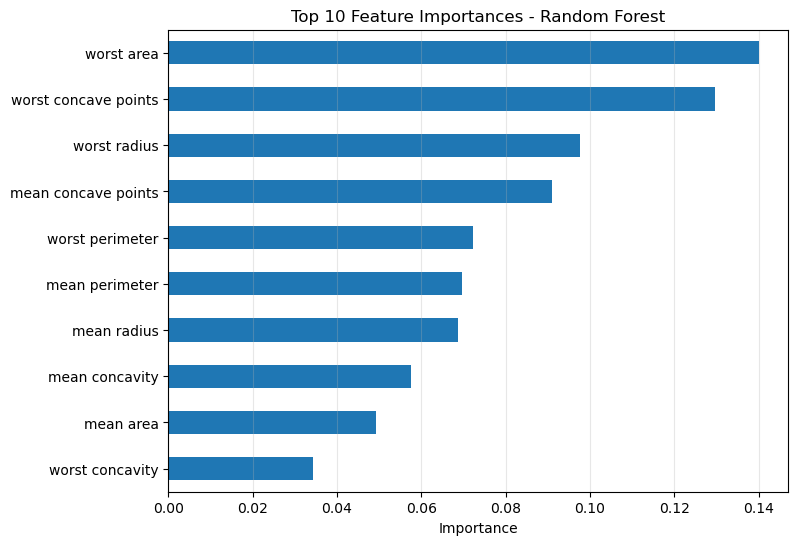

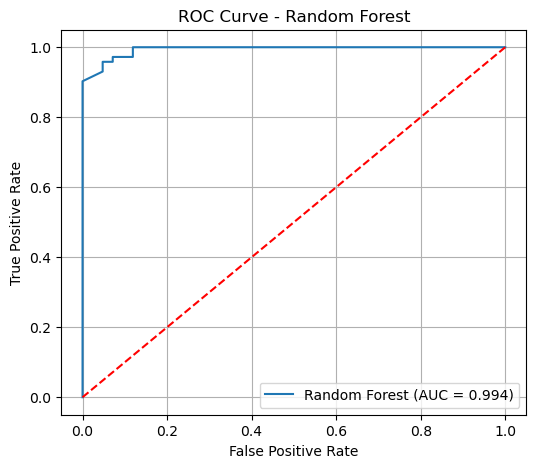

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters (CV):")
print(grid.best_params_)

best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\n========== RANDOM FOREST TEST RESULTS ==========")
print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(auc,4))

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,6))
top10[::-1].plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.grid(axis="x", alpha=0.3)
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],'--',color='red')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()